## Random Forest classifier Benchmark


In this Jupyter Notebook we will realise the training and testing of a Random Forest classifier on the League of Legends dataset. We will use the Random Forest classifier from the scikit-learn library. We will also use the pandas library to manipulate the data and the matplotlib library to plot the results.


In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

BASE_DIR = "../datasets/"


## Training, Testing and Evaluations fonctions

In [5]:
def load_data():
    challenger_dataset = pd.read_csv(BASE_DIR + "challenger_dataset.csv")
    master_dataset = pd.read_csv(BASE_DIR + "master_dataset.csv")
    return challenger_dataset, master_dataset

In [6]:
def k_fold_cross_validation(model, X, y, k=5):
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    histories = []

    model_name = "Model number "
    idx = 0

    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = RandomForestClassifier(n_jobs=-2)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        conf_matrix = confusion_matrix(y_test, y_pred)
        class_report = classification_report(y_test, y_pred, output_dict=True)
        print(class_report)
        idx += 1

        histories.append({
            'model_name': model_name + str(idx),
            'model': model,
            'accuracy': accuracy,
            'confusion_matrix': conf_matrix,
            'classification_report': class_report,
            'y_test': y_test,
            'y_pred': y_pred
        })

    return histories

In [7]:
def plot_results(histories):
    model_names = [h['model_name'] for h in histories]
    accuracies = [h['accuracy'] for h in histories]
    precisions = [h['classification_report']['weighted avg']['precision'] for h in histories]
    recalls = [h['classification_report']['weighted avg']['recall'] for h in histories]
    f1_scores = [h['classification_report']['weighted avg']['f1-score'] for h in histories]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy Bar Chart
    axes[0].bar(model_names, accuracies, color='skyblue')
    axes[0].set_title('Model Accuracy Comparison')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_ylim(0, 1)
    axes[0].set_xticks(range(len(model_names)))
    axes[0].set_xticklabels(model_names, rotation=45, ha='right')

    # Precision, Recall, F1-score Comparison
    x = np.arange(len(model_names))
    width = 0.2

    axes[1].bar(x - width, precisions, width, label='Precision', color='lightcoral')
    axes[1].bar(x, recalls, width, label='Recall', color='lightgreen')
    axes[1].bar(x + width, f1_scores, width, label='F1-Score', color='lightskyblue')

    axes[1].set_title('Precision, Recall, and F1-Score')
    axes[1].set_ylabel('Score')
    axes[1].set_ylim(0, 1)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(model_names, rotation=45, ha='right')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [8]:
def fine_tune_random_forest(X, y, param_grid, k=5):
    model = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(model, param_grid, cv=k, n_jobs=-1, scoring='accuracy', verbose=2)
    grid_search.fit(X, y)
    best_model = grid_search.best_estimator_
    print("Best Model Parameters: ", grid_search.best_params_)
    return best_model

In [9]:
challenge_data, master_data = load_data()

# Replace inf values with NaN
challenge_data.replace([np.inf, -np.inf], np.nan, inplace=True)
master_data.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean of the column
challenge_data.fillna(challenge_data.mean(), inplace=True)
master_data.fillna(master_data.mean(), inplace=True)

kfold_histories = k_fold_cross_validation(RandomForestClassifier(), challenge_data.drop('winner', axis=1), challenge_data['winner'], k=10)


{'0': {'precision': 0.7633933670943913, 'recall': 0.8113390797620493, 'f1-score': 0.7866363244006749, 'support': 24711.0}, '1': {'precision': 0.7855269816442011, 'recall': 0.7331787539181588, 'f1-score': 0.758450672944521, 'support': 23289.0}, 'accuracy': 0.7734166666666666, 'macro avg': {'precision': 0.7744601743692963, 'recall': 0.7722589168401041, 'f1-score': 0.7725434986725979, 'support': 48000.0}, 'weighted avg': {'precision': 0.7741323202037772, 'recall': 0.7734166666666666, 'f1-score': 0.7729609986347922, 'support': 48000.0}}
{'0': {'precision': 0.7588804343669943, 'recall': 0.8079052348774729, 'f1-score': 0.7826258404148346, 'support': 24566.0}, '1': {'precision': 0.783987915407855, 'recall': 0.7308923313276149, 'f1-score': 0.7565096402305704, 'support': 23433.0}, 'accuracy': 0.7703077147440571, 'macro avg': {'precision': 0.7714341748874246, 'recall': 0.769398783102544, 'f1-score': 0.7695677403227026, 'support': 47999.0}, 'weighted avg': {'precision': 0.7711378481304162, 'recal

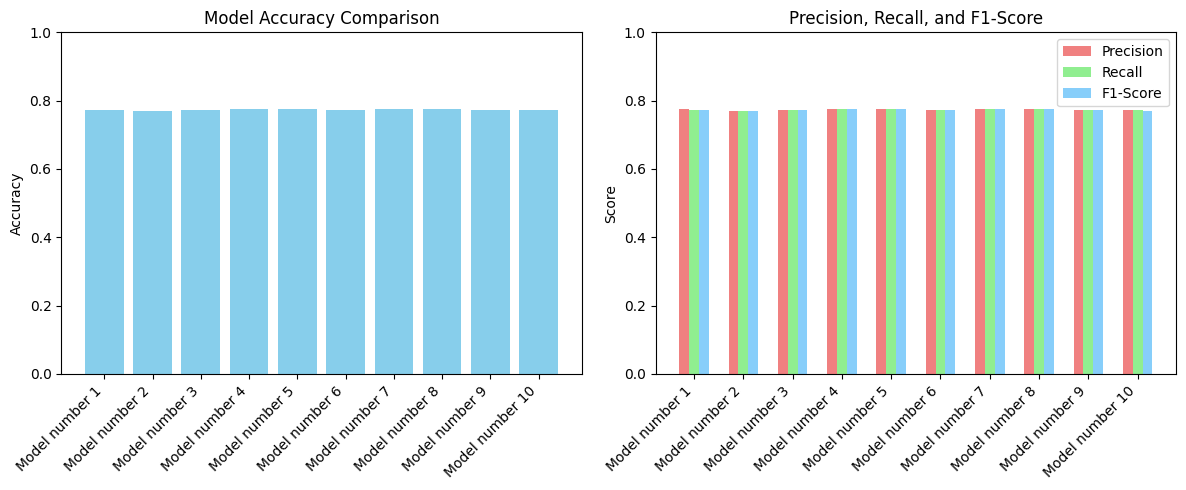

In [10]:
plot_results(kfold_histories)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  53.0s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  55.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  55.9s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  57.4s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=  57.8s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.9min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time= 1.9min
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  58.1s
[CV] END max_depth=10, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=  58.6s
[CV] END max_depth=10, min_samples_le

/home/youngsnow/Documents/UniversityKent/AISystemImpl/LeagueOfLegendsModelBenchmark/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 3.2min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time= 3.3min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time= 1.6min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=50; total time= 1.5min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.7min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.2min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.5min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.1min
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=5, n_estimators=100; total time= 2.2min
Best Model Parameters:  {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_e

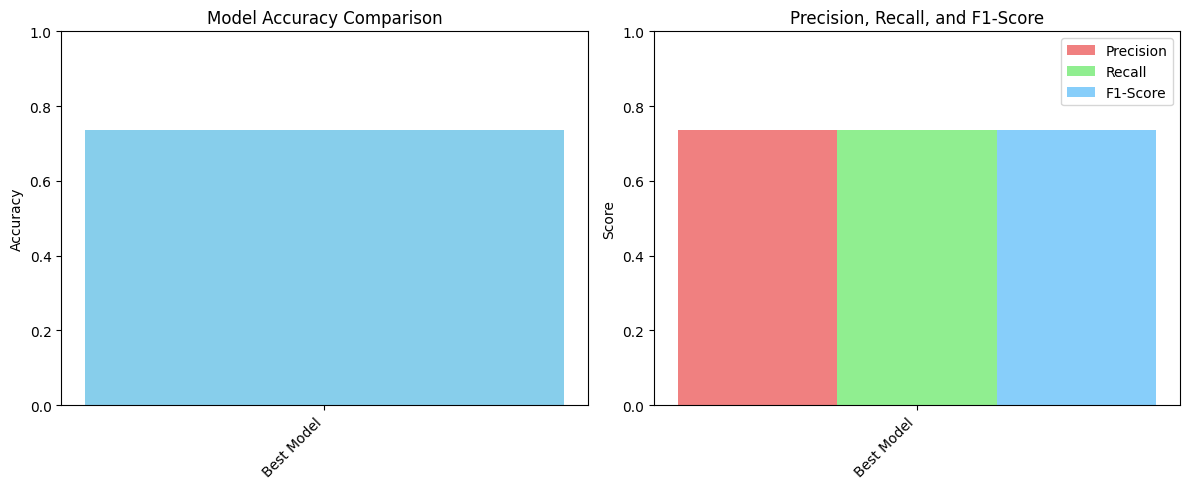

In [18]:
best_model = fine_tune_random_forest(challenge_data.drop('winner', axis=1), challenge_data['winner'], {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
})

print("Best Model: ", best_model)

best_model.fit(challenge_data.drop('winner', axis=1), challenge_data['winner'])
y_pred = best_model.predict(master_data.drop('winner', axis=1))
accuracy = accuracy_score(master_data['winner'], y_pred)
conf_matrix = confusion_matrix(master_data['winner'], y_pred)
class_report = classification_report(master_data['winner'], y_pred, output_dict=True)

plot_results([{
    'model_name': 'Best Model',
    'model': best_model,
    'accuracy': accuracy,
    'confusion_matrix': conf_matrix,
    'classification_report': class_report,
    'y_test': master_data['winner'],
    'y_pred': y_pred
}])



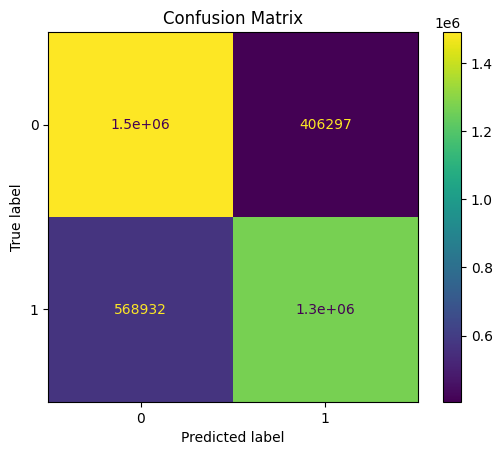

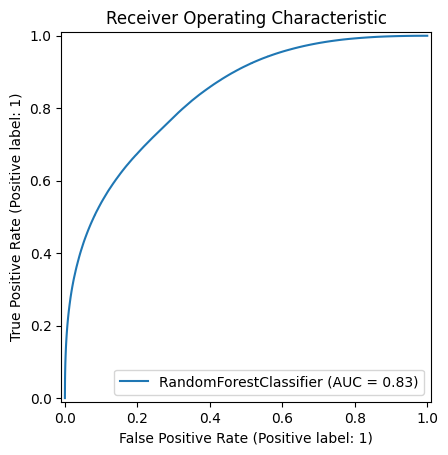

Brier Score: 0.1661341654559955


In [12]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, ConfusionMatrixDisplay, brier_score_loss
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# To avoid running the Hyperparameter tuning again
try:
    best_params = best_model.get_params()
except:
    best_params = {
        'n_estimators': 100,
        'max_depth': 20,
        'min_samples_split': 2,
        'min_samples_leaf': 1
    }

# Train a new model using the best model's parameters
new_model = RandomForestClassifier(**best_params)
new_model.fit(challenge_data.drop('winner', axis=1), challenge_data['winner'])

# Predict on the master data
y_pred_new = new_model.predict(master_data.drop('winner', axis=1))
y_prob_new = new_model.predict_proba(master_data.drop('winner', axis=1))[:, 1]

# Plot the confusion matrix
ConfusionMatrixDisplay.from_estimator(new_model, master_data.drop('winner', axis=1), master_data['winner'])
plt.title('Confusion Matrix')
plt.show()

# Plot the ROC curve and calculate the AUC-ROC
RocCurveDisplay.from_estimator(new_model, master_data.drop('winner', axis=1), master_data['winner'])
plt.title('Receiver Operating Characteristic')
plt.show()

# Calculate the Brier score
brier_score = brier_score_loss(master_data['winner'], y_prob_new)
print(f'Brier Score: {brier_score}')
